# 🌲 Decision Tree vs Random Forest — Diabetes Veri Seti

Bu çalışmada aynı veri seti üzerinde **iki farklı makine öğrenmesi modeli** karşılaştırılmaktadır:

| Model | Açıklama |
|---|---|
| **Decision Tree** | Tek bir karar ağacı — basit, yorumlanabilir |
| **Random Forest** | Yüzlerce ağacın birleşimi — güçlü, kararlı |

**Veri Seti:** Pima Indians Diabetes Dataset  
**Hedef:** Kişinin diyabetli olup olmadığını tahmin etmek (0 = Değil, 1 = Diyabetli)

## 1. Kütüphaneler

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print('Kütüphaneler yüklendi ✅')

Kütüphaneler yüklendi ✅


## 2. Veri Setini Yükle

In [2]:
path = kagglehub.dataset_download('pritsheta/diabetes-dataset')
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f'Veri seti boyutu: {df.shape}')
print(f'Sütunlar: {df.columns.tolist()}')
print(f'\nSınıf dağılımı:')
print(df['Outcome'].value_counts())
df.head()

100%|██████████| 8.91k/8.91k [00:00<00:00, 15.4MB/s]

Extracting files...
Veri seti boyutu: (768, 9)
Sütunlar: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Sınıf dağılımı:
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 3. Veri Keşfi (EDA)

In [3]:
print(df.info())
print('\nEksik değer kontrolü:')
print(df.isnull().sum())
print('\nİstatistiksel özet:')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Eksik değer kontrolü:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Ag

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


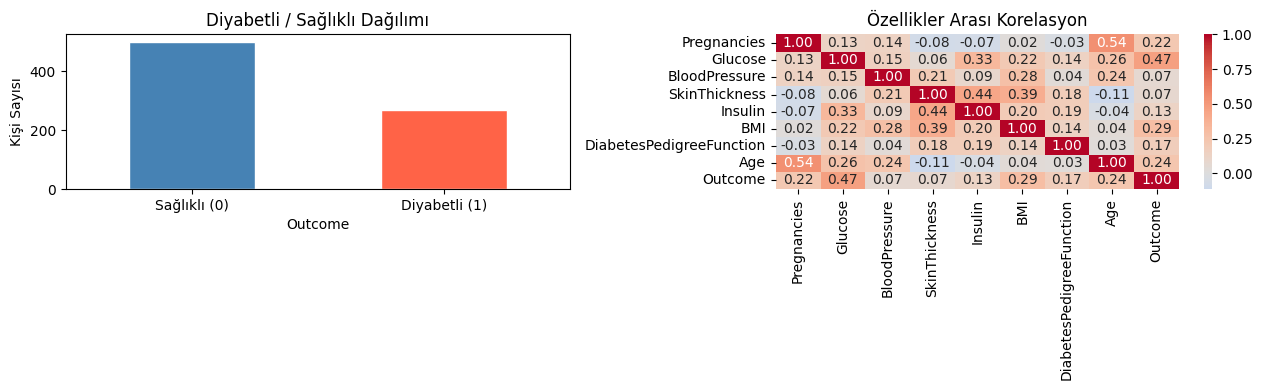

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sınıf dağılımı
df['Outcome'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_title('Diyabetli / Sağlıklı Dağılımı')
axes[0].set_xticklabels(['Sağlıklı (0)', 'Diyabetli (1)'], rotation=0)
axes[0].set_ylabel('Kişi Sayısı')

# Korelasyon ısı haritası
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1])
axes[1].set_title('Özellikler Arası Korelasyon')

plt.tight_layout()
plt.show()

## 4. Veriyi Hazırla

In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Eğitim seti : {X_train.shape[0]} örnek')
print(f'Test seti   : {X_test.shape[0]} örnek')
print(f'\nEğitim - Sınıf dağılımı:')
print(y_train.value_counts())
print(f'\nTest - Sınıf dağılımı:')
print(y_test.value_counts())

Eğitim seti : 537 örnek
Test seti   : 231 örnek

Eğitim - Sınıf dağılımı:
Outcome
0    350
1    187
Name: count, dtype: int64

Test - Sınıf dağılımı:
Outcome
0    150
1     81
Name: count, dtype: int64


---
# 🌿 MODEL 1: Decision Tree

**Decision Tree (Karar Ağacı):** Veriyi "evet/hayır" sorularıyla bölen, ağaç yapısında görselleştirilebilen bir algoritmadır.

### Temel Parametreler:
- `criterion='gini'` → Düğüm saflığını Gini impurity ile ölçer (0 = tamamen saf)
- `max_depth=3` → Ağacın maksimum derinliği (overfitting önlemek için sınırlandırılır)
- `min_samples_split=10` → Bir düğümün bölünmesi için gereken minimum örnek sayısı
- `min_samples_leaf=3` → Yaprak düğümdeki minimum örnek sayısı

In [6]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=42
)

dt_model.fit(X_train, y_train)
print('Decision Tree eğitildi ✅')

Decision Tree eğitildi ✅


In [7]:
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

dt_acc  = accuracy_score(y_test, dt_pred)
dt_auc  = roc_auc_score(y_test, dt_prob)
dt_train_acc = dt_model.score(X_train, y_train)

print('=== DECISION TREE SONUÇLARI ===')
print(f'  Eğitim Doğruluğu : %{dt_train_acc*100:.2f}')
print(f'  Test Doğruluğu   : %{dt_acc*100:.2f}')
print(f'  AUC Skoru        : {dt_auc:.4f}')
print()
if dt_train_acc - dt_acc > 0.1:
    print('⚠️  Overfitting var (eğitim-test farkı > %10)')
elif dt_train_acc - dt_acc > 0.05:
    print('⚠️  Hafif overfitting olabilir')
else:
    print('✅ Model genellemesi iyi (overfitting yok)')

print('\n=== SINIFLANDIRMA RAPORU ===')
print(classification_report(y_test, dt_pred, target_names=['Sağlıklı (0)', 'Diyabetli (1)']))

=== DECISION TREE SONUÇLARI ===
  Eğitim Doğruluğu : %78.96
  Test Doğruluğu   : %72.73
  AUC Skoru        : 0.7952

⚠️  Hafif overfitting olabilir

=== SINIFLANDIRMA RAPORU ===
               precision    recall  f1-score   support

 Sağlıklı (0)       0.75      0.86      0.80       150
Diyabetli (1)       0.65      0.48      0.55        81

     accuracy                           0.73       231
    macro avg       0.70      0.67      0.68       231
 weighted avg       0.72      0.73      0.72       231



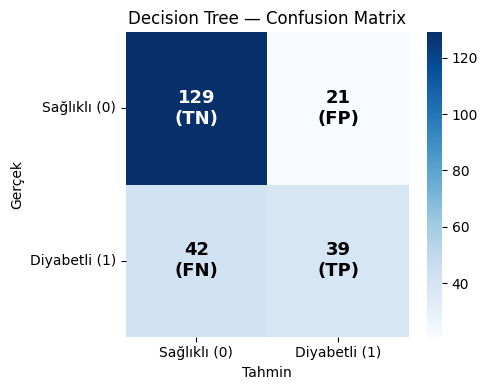

TN (Doğru Negatif): 129 → Sağlıklıları doğru tahmin etti
FP (Yanlış Pozitif): 21 → Sağlıklıları yanlışlıkla diyabetli dedi
FN (Yanlış Negatif): 42 → Diyabetlileri yanlışlıkla sağlıklı dedi ⚠️
TP (Doğru Pozitif): 39 → Diyabetlileri doğru tahmin etti


In [8]:
# Confusion Matrix — Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
etiketler = [['TN', 'FP'], ['FN', 'TP']]

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=False, cmap='Blues', fmt='d')
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.5,
            f'{cm_dt[i,j]}\n({etiketler[i][j]})',
            ha='center', va='center', fontsize=13, fontweight='bold',
            color='white' if cm_dt[i,j] > cm_dt.max()/2 else 'black'
        )
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.title('Decision Tree — Confusion Matrix')
plt.xticks([0.5, 1.5], ['Sağlıklı (0)', 'Diyabetli (1)'])
plt.yticks([0.5, 1.5], ['Sağlıklı (0)', 'Diyabetli (1)'], rotation=0)
plt.tight_layout()
plt.show()

print(f'TN (Doğru Negatif): {cm_dt[0,0]} → Sağlıklıları doğru tahmin etti')
print(f'FP (Yanlış Pozitif): {cm_dt[0,1]} → Sağlıklıları yanlışlıkla diyabetli dedi')
print(f'FN (Yanlış Negatif): {cm_dt[1,0]} → Diyabetlileri yanlışlıkla sağlıklı dedi ⚠️')
print(f'TP (Doğru Pozitif): {cm_dt[1,1]} → Diyabetlileri doğru tahmin etti')

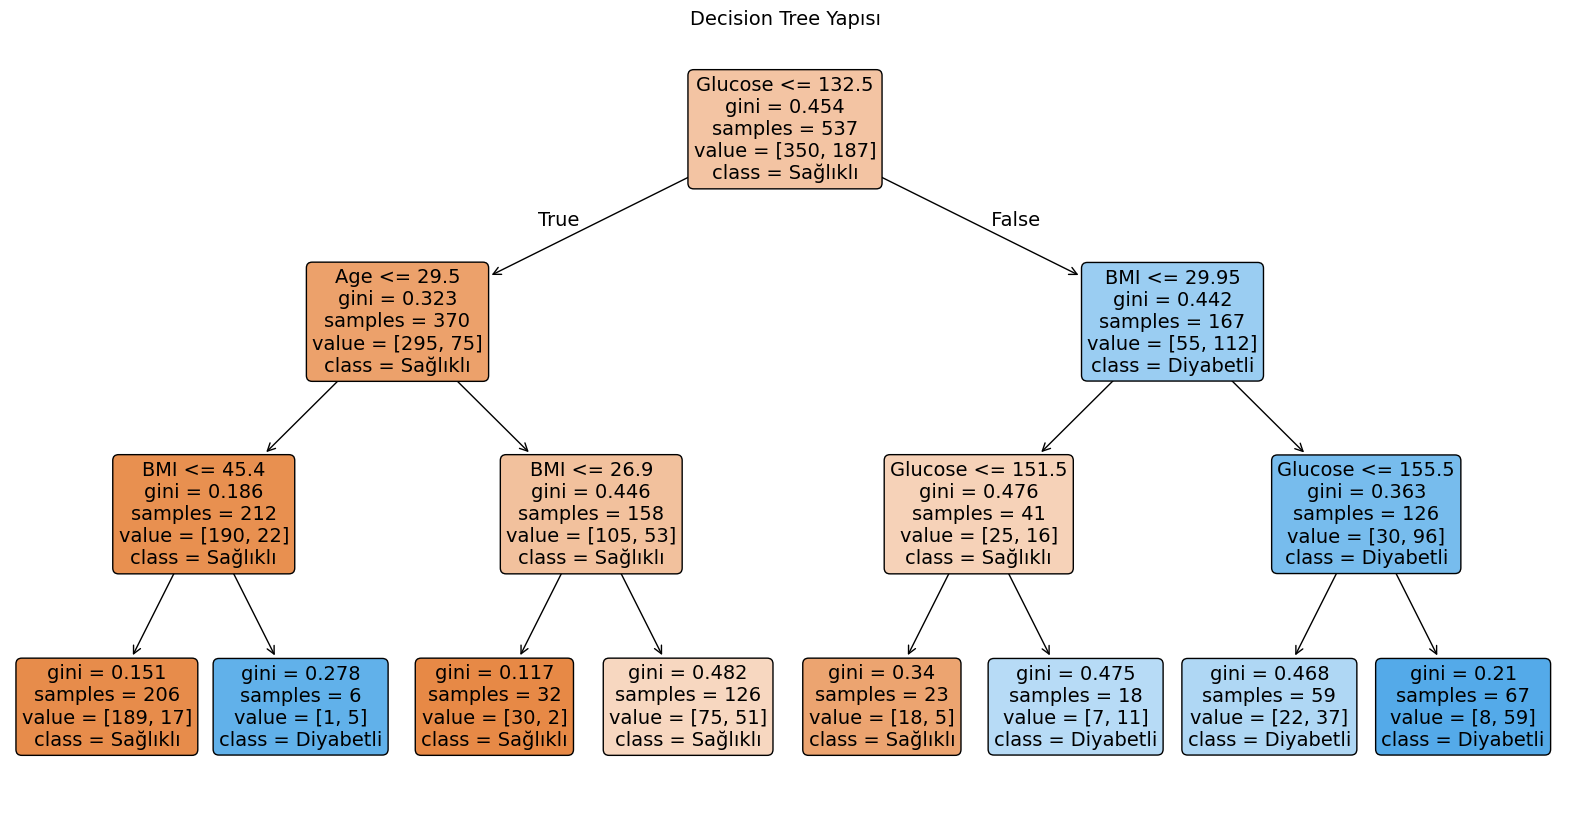

In [9]:
# Karar ağacı görselleştirme
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['Sağlıklı', 'Diyabetli'],
    filled=True,
    rounded=True
)
plt.title('Decision Tree Yapısı', fontsize=14)
plt.show()

In [10]:
# Kural metni
tree_rules = export_text(dt_model, feature_names=list(X.columns), spacing=3)
print('=== KARAR AĞACI KURALLARI ===')
print(tree_rules)

=== KARAR AĞACI KURALLARI ===
|--- Glucose <= 132.50
|   |--- Age <= 29.50
|   |   |--- BMI <= 45.40
|   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- class: 1
|   |--- Age >  29.50
|   |   |--- BMI <= 26.90
|   |   |   |--- class: 0
|   |   |--- BMI >  26.90
|   |   |   |--- class: 0
|--- Glucose >  132.50
|   |--- BMI <= 29.95
|   |   |--- Glucose <= 151.50
|   |   |   |--- class: 0
|   |   |--- Glucose >  151.50
|   |   |   |--- class: 1
|   |--- BMI >  29.95
|   |   |--- Glucose <= 155.50
|   |   |   |--- class: 1
|   |   |--- Glucose >  155.50
|   |   |   |--- class: 1



**Karar ağacı incelendiğinde** en belirleyici değişkenin **Glucose** olduğu görülmektedir. Model ilk ayrımı glukoz değerine göre yapmış; düşük glukoz → Sağlıklı, yüksek glukoz → Diyabetli yönünde karar vermiştir. İkinci seviyede **BMI** ve **Age** değişkenleri devreye girmiştir. `max_depth=3` ile ağacın derinliği sınırlandırılarak overfitting riski azaltılmıştır.

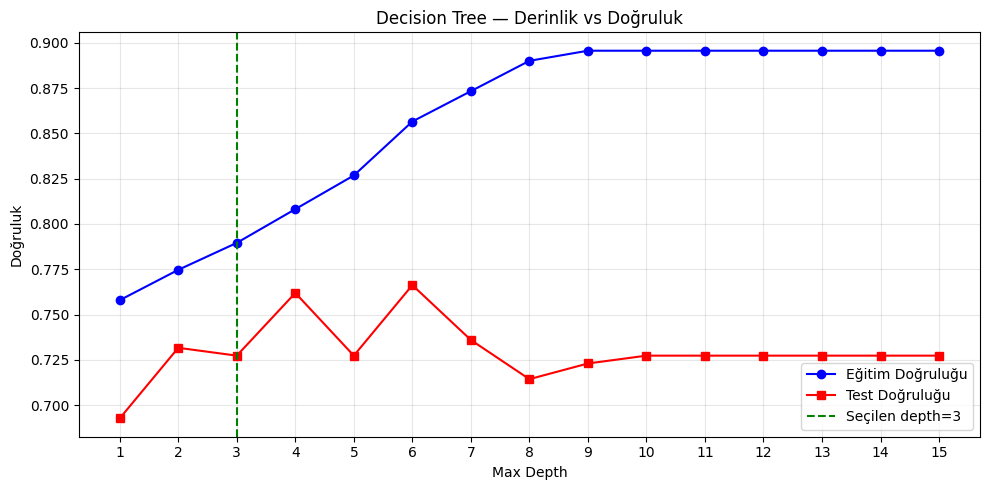

In [11]:
# Derinlik-Doğruluk ilişkisi
depths = range(1, 16)
dt_train_scores, dt_test_scores = [], []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth, criterion='gini',
        min_samples_split=10, min_samples_leaf=5, random_state=42
    )
    dt.fit(X_train, y_train)
    dt_train_scores.append(dt.score(X_train, y_train))
    dt_test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, dt_train_scores, 'b-o', label='Eğitim Doğruluğu')
plt.plot(depths, dt_test_scores, 'r-s', label='Test Doğruluğu')
plt.axvline(3, color='green', linestyle='--', label='Seçilen depth=3')
plt.xlabel('Max Depth')
plt.ylabel('Doğruluk')
plt.title('Decision Tree — Derinlik vs Doğruluk')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()

---
# 🌳 MODEL 2: Random Forest

**Random Forest (Rastgele Orman):** Yüzlerce farklı Decision Tree'yi eğitip çoğunluk oyuyla tahmin yapan bir **ensemble (topluluk)** yöntemidir.

### Neden Random Forest daha iyi olabilir?
- Tek bir ağaç hata yapabilir, ama 100 ağacın çoğunluğu genellikle daha doğrudur
- Her ağaç rastgele özellikler kullandığından overfitting riski azalır
- Daha kararlı ve genelleşebilir tahminler üretir

### Temel Parametreler:
- `n_estimators=100` → Kaç tane ağaç oluşturulacak
- `max_depth=5` → Her ağacın maksimum derinliği
- `max_features='sqrt'` → Her bölünmede kaç özellik denenecek (karekök kadar)

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)
print('Random Forest eğitildi ✅')

Random Forest eğitildi ✅


In [13]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf_prob)
rf_train_acc = rf_model.score(X_train, y_train)

print('=== RANDOM FOREST SONUÇLARI ===')
print(f'  Eğitim Doğruluğu : %{rf_train_acc*100:.2f}')
print(f'  Test Doğruluğu   : %{rf_acc*100:.2f}')
print(f'  AUC Skoru        : {rf_auc:.4f}')
print()
if rf_train_acc - rf_acc > 0.1:
    print('⚠️  Overfitting var (eğitim-test farkı > %10)')
elif rf_train_acc - rf_acc > 0.05:
    print('⚠️  Hafif overfitting olabilir')
else:
    print('✅ Model genellemesi iyi (overfitting yok)')

print('\n=== SINIFLANDIRMA RAPORU ===')
print(classification_report(y_test, rf_pred, target_names=['Sağlıklı (0)', 'Diyabetli (1)']))

=== RANDOM FOREST SONUÇLARI ===
  Eğitim Doğruluğu : %85.10
  Test Doğruluğu   : %74.03
  AUC Skoru        : 0.8295

⚠️  Overfitting var (eğitim-test farkı > %10)

=== SINIFLANDIRMA RAPORU ===
               precision    recall  f1-score   support

 Sağlıklı (0)       0.76      0.87      0.81       150
Diyabetli (1)       0.67      0.51      0.58        81

     accuracy                           0.74       231
    macro avg       0.72      0.69      0.69       231
 weighted avg       0.73      0.74      0.73       231



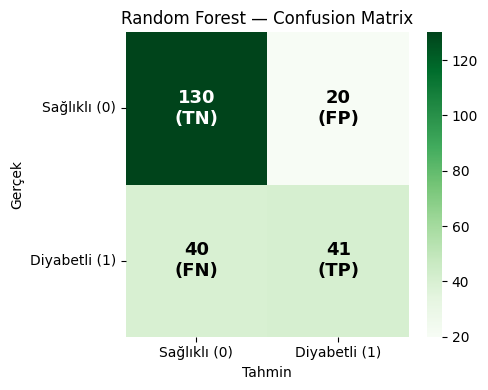

TN (Doğru Negatif): 130
FP (Yanlış Pozitif): 20
FN (Yanlış Negatif): 40 ⚠️ (diyabetliyi kaçırma)
TP (Doğru Pozitif): 41


In [14]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=False, cmap='Greens', fmt='d')
for i in range(2):
    for j in range(2):
        plt.text(j+0.5, i+0.5,
            f'{cm_rf[i,j]}\n({etiketler[i][j]})',
            ha='center', va='center', fontsize=13, fontweight='bold',
            color='white' if cm_rf[i,j] > cm_rf.max()/2 else 'black'
        )
plt.xlabel('Tahmin')
plt.ylabel('Gerçek')
plt.title('Random Forest — Confusion Matrix')
plt.xticks([0.5, 1.5], ['Sağlıklı (0)', 'Diyabetli (1)'])
plt.yticks([0.5, 1.5], ['Sağlıklı (0)', 'Diyabetli (1)'], rotation=0)
plt.tight_layout()
plt.show()

print(f'TN (Doğru Negatif): {cm_rf[0,0]}')
print(f'FP (Yanlış Pozitif): {cm_rf[0,1]}')
print(f'FN (Yanlış Negatif): {cm_rf[1,0]} ⚠️ (diyabetliyi kaçırma)')
print(f'TP (Doğru Pozitif): {cm_rf[1,1]}')

/tmp/ipykernel_7747/1181036912.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_fi, x='importance', y='feature', palette='viridis')


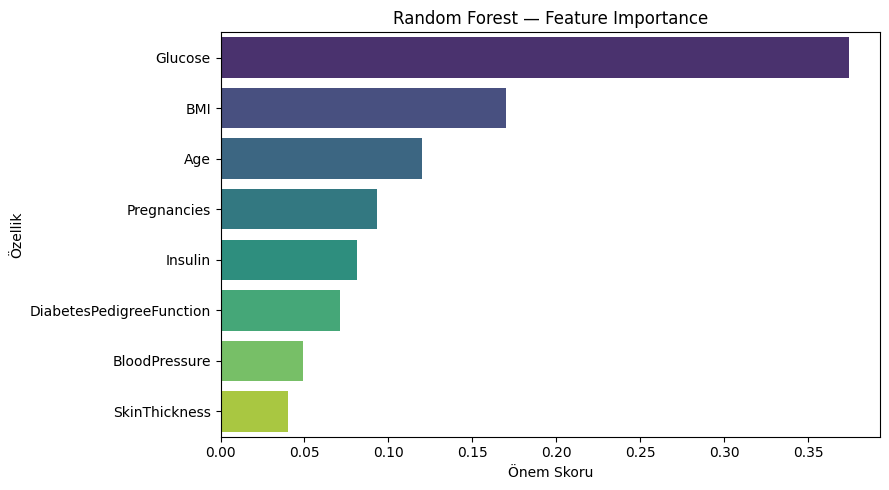

En önemli 3 özellik:
feature  importance
Glucose    0.374195
    BMI    0.169924
    Age    0.120082


In [15]:
# Feature Importance — Random Forest
rf_fi = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=rf_fi, x='importance', y='feature', palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Önem Skoru')
plt.ylabel('Özellik')
plt.tight_layout()
plt.show()

print('En önemli 3 özellik:')
print(rf_fi.head(3).to_string(index=False))

---
# 📊 KARŞILAŞTIRMA: Decision Tree vs Random Forest

In [16]:
# Karşılaştırma tablosu
karsilastirma = pd.DataFrame({
    'Metrik': [
        'Eğitim Doğruluğu', 'Test Doğruluğu', 'AUC-ROC',
        'Precision (Diyabetli)', 'Recall (Diyabetli)', 'F1-Score (Diyabetli)'
    ],
    'Decision Tree': [
        f'%{dt_train_acc*100:.2f}',
        f'%{dt_acc*100:.2f}',
        f'{dt_auc:.4f}',
        f"{classification_report(y_test, dt_pred, output_dict=True)['1']['precision']:.2f}",
        f"{classification_report(y_test, dt_pred, output_dict=True)['1']['recall']:.2f}",
        f"{classification_report(y_test, dt_pred, output_dict=True)['1']['f1-score']:.2f}"
    ],
    'Random Forest': [
        f'%{rf_train_acc*100:.2f}',
        f'%{rf_acc*100:.2f}',
        f'{rf_auc:.4f}',
        f"{classification_report(y_test, rf_pred, output_dict=True)['1']['precision']:.2f}",
        f"{classification_report(y_test, rf_pred, output_dict=True)['1']['recall']:.2f}",
        f"{classification_report(y_test, rf_pred, output_dict=True)['1']['f1-score']:.2f}"
    ]
})

print('=== MODEL KARŞILAŞTIRMA TABLOSU ===')
print(karsilastirma.to_string(index=False))

=== MODEL KARŞILAŞTIRMA TABLOSU ===
               Metrik Decision Tree Random Forest
     Eğitim Doğruluğu        %78.96        %85.10
       Test Doğruluğu        %72.73        %74.03
              AUC-ROC        0.7952        0.8295
Precision (Diyabetli)          0.65          0.67
   Recall (Diyabetli)          0.48          0.51
 F1-Score (Diyabetli)          0.55          0.58


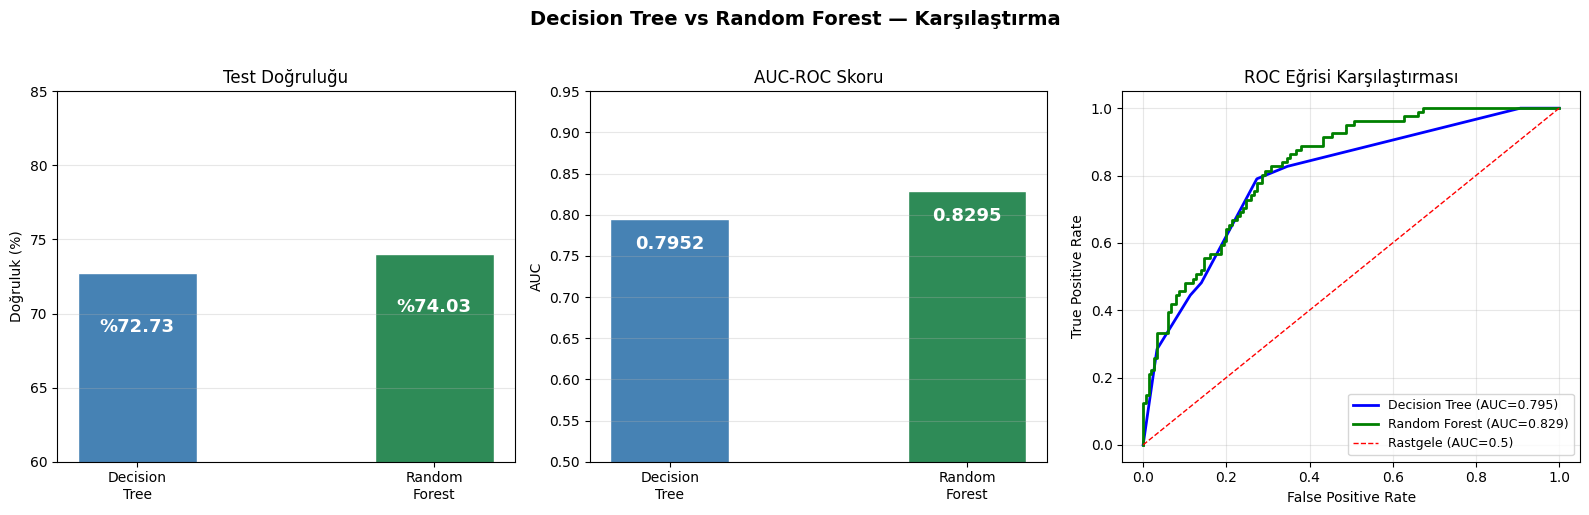

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafik 1: Accuracy karşılaştırması
modeller = ['Decision\nTree', 'Random\nForest']
test_accs = [dt_acc*100, rf_acc*100]
renkler   = ['steelblue', 'seagreen']

bars = axes[0].bar(modeller, test_accs, color=renkler, width=0.4, edgecolor='white')
for bar, val in zip(bars, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 3,
                 f'%{val:.2f}', ha='center', va='top', fontsize=13,
                 fontweight='bold', color='white')
axes[0].set_title('Test Doğruluğu')
axes[0].set_ylabel('Doğruluk (%)')
axes[0].set_ylim(60, 85)
axes[0].grid(axis='y', alpha=0.3)

# Grafik 2: AUC karşılaştırması
aucs = [dt_auc, rf_auc]
bars2 = axes[1].bar(modeller, aucs, color=renkler, width=0.4, edgecolor='white')
for bar, val in zip(bars2, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.02,
                 f'{val:.4f}', ha='center', va='top', fontsize=13,
                 fontweight='bold', color='white')
axes[1].set_title('AUC-ROC Skoru')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0.5, 0.95)
axes[1].grid(axis='y', alpha=0.3)

# Grafik 3: ROC Eğrileri yan yana
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

axes[2].plot(fpr_dt, tpr_dt, 'b-', linewidth=2, label=f'Decision Tree (AUC={dt_auc:.3f})')
axes[2].plot(fpr_rf, tpr_rf, 'g-', linewidth=2, label=f'Random Forest (AUC={rf_auc:.3f})')
axes[2].plot([0,1],[0,1],'r--', linewidth=1, label='Rastgele (AUC=0.5)')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Eğrisi Karşılaştırması')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle('Decision Tree vs Random Forest — Karşılaştırma', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

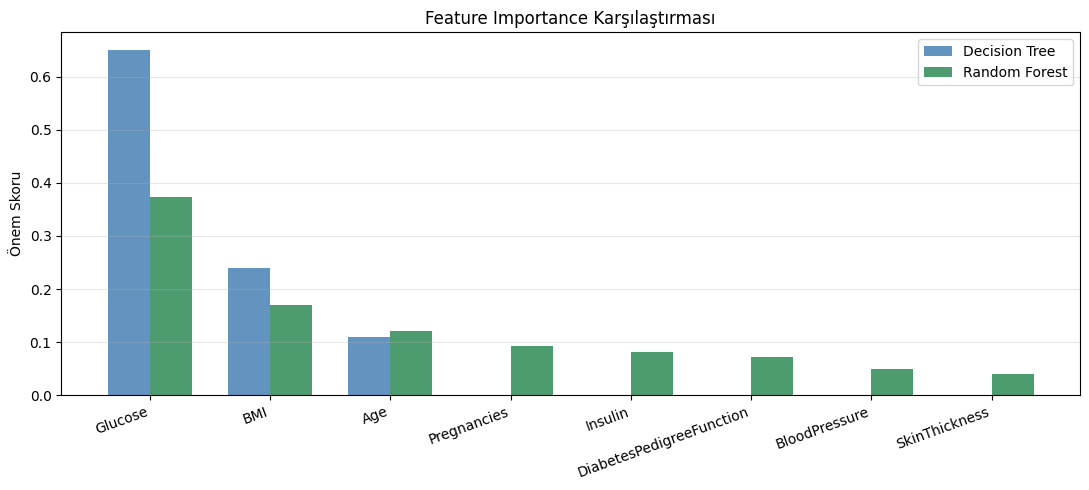

In [18]:
# Feature Importance karşılaştırması
dt_fi = pd.DataFrame({
    'feature': X.columns,
    'dt_importance': dt_model.feature_importances_,
    'rf_importance': rf_model.feature_importances_
}).sort_values('rf_importance', ascending=False)

x = np.arange(len(dt_fi))
w = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - w/2, dt_fi['dt_importance'], w, label='Decision Tree', color='steelblue', alpha=0.85)
plt.bar(x + w/2, dt_fi['rf_importance'], w, label='Random Forest', color='seagreen', alpha=0.85)
plt.xticks(x, dt_fi['feature'], rotation=20, ha='right')
plt.ylabel('Önem Skoru')
plt.title('Feature Importance Karşılaştırması')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 🎯 Genel Sonuç

In [22]:
kazanan = 'Random Forest' if rf_acc > dt_acc else 'Decision Tree'

print('=== PROJE SONUÇ ÖZETI ===')
print(f'  Veri Seti          : Pima Indians Diabetes Dataset')
print(f'  Görev              : İkili Sınıflandırma (Diyabet var/yok)')
print()
print(f'  Decision Tree Test Doğruluğu : %{dt_acc*100:.2f} | AUC: {dt_auc:.4f}')
print(f'  Random Forest Test Doğruluğu : %{rf_acc*100:.2f} | AUC: {rf_auc:.4f}')
print()
print(f'  🏆 Kazanan Model: {kazanan}')
print()
print('  📌 Yorumlar:')
print('  - Random Forest, birden fazla ağacın birleşimi olduğu için')
print('    Decision Treeye kıyasla daha kararlı ve genelleşebilir sonuçlar üretir.')
print('  - Decision Tree daha yorumlanabilir (kurallar görselleştirilebilir),')
print('    ancak tek ağaç overfittinge daha eğilimlidir.')
print('  - Her iki modelde de en belirleyici özellik Glucose olmuştur.')

=== PROJE SONUÇ ÖZETI ===
  Veri Seti          : Pima Indians Diabetes Dataset
  Görev              : İkili Sınıflandırma (Diyabet var/yok)

  Decision Tree Test Doğruluğu : %72.73 | AUC: 0.7952
  Random Forest Test Doğruluğu : %74.03 | AUC: 0.8295

  🏆 Kazanan Model: Random Forest

  📌 Yorumlar:
  - Random Forest, birden fazla ağacın birleşimi olduğu için
    Decision Treeye kıyasla daha kararlı ve genelleşebilir sonuçlar üretir.
  - Decision Tree daha yorumlanabilir (kurallar görselleştirilebilir),
    ancak tek ağaç overfittinge daha eğilimlidir.
  - Her iki modelde de en belirleyici özellik Glucose olmuştur.


## 📋 Kavramlar Özet Tablosu

| Kavram | Açıklama |
|---|---|
| **Gini impurity** | Düğümdeki karışıklık ölçüsü — 0'a yakın = daha saf |
| **max_depth** | Ağacın maksimum dal derinliği |
| **Overfitting** | Modelin eğitim verisini ezberleme, yeni veride başarısız olma durumu |
| **Ensemble** | Birden fazla modeli birleştirerek daha güçlü tahmin yapma |
| **Feature Importance** | Her özelliğin tahmine katkısı |
| **Recall** | Gerçek pozitiflerin ne kadarını yakaladı (FN için kritik) |
| **AUC-ROC** | Modelin tüm eşiklerde ortalama performansı (1'e yakın = iyi) |